In [4]:
import pandas as pd
import statsmodels.formula.api as smf
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Linear Metrics
calculation for linear pose metrics are under process_pose/linear_pose.py

## Stats

In [3]:
DATA_FILE = "data/linear_pose_metrics/experimental_pose_metrics.csv" # change to bsl if needed
OUTPUT_FILE = "exp_pose_lin_table.tex"

df = pd.read_csv(DATA_FILE)

non_metric_cols = {'participant', 'condition', 'window_index', 'window_start', 'window_end'}
metric_cols = [col for col in df.columns if col not in non_metric_cols]

df['condition'] = df['condition'].astype('category')
df['condition'] = df['condition'].cat.reorder_categories(['L', 'M', 'H'], ordered=True)

def split_metric_name(name):
    name = name.replace("avg", "Average").replace("dist", "Amplitude")
    name = name.replace("mean_abs_", "").replace("mean_abs", "")
    name = name.replace("_", " ").title()
    parts = name.split()
    if len(parts) < 2:
        return name, ""
    region = " ".join(parts[:-1])
    metric = parts[-1]
    return region, metric

grouped_rows = defaultdict(list)

for metric in metric_cols:
    temp_df = df[['participant', 'condition', metric]].dropna()

    if not all(c in temp_df['condition'].unique() for c in ['L', 'M', 'H']):
        continue

    try:
        model_l = smf.mixedlm(f"{metric} ~ condition", data=temp_df, groups=temp_df['participant'])
        result_l = model_l.fit(method='lbfgs')

        # Subset for M vs H comparison
        temp_df_hm = temp_df[temp_df['condition'].isin(['M', 'H'])].copy()
        temp_df_hm['condition'] = temp_df_hm['condition'].cat.remove_unused_categories()
        temp_df_hm['condition'] = temp_df_hm['condition'].cat.reorder_categories(['M', 'H'], ordered=True)

        model_hm = smf.mixedlm(f"{metric} ~ condition", data=temp_df_hm, groups=temp_df_hm['participant'])
        result_hm = model_hm.fit(method='lbfgs')

        coefs_l = result_l.params
        pvals_l = result_l.pvalues
        coefs_hm = result_hm.params
        pvals_hm = result_hm.pvalues

        def format_stat(beta, pval):
            beta_str = f"$\\beta = {beta:.3f}$" if pd.notnull(beta) else "--"
            p_str = r"$p < .001$" if pval < 0.001 else f"$p = {pval:.3f}$" if pd.notnull(pval) else "--"
            return beta_str, p_str

        beta_m, p_m = format_stat(coefs_l.get('condition[T.M]', float('nan')), pvals_l.get('condition[T.M]', float('nan')))
        beta_h, p_h = format_stat(coefs_l.get('condition[T.H]', float('nan')), pvals_l.get('condition[T.H]', float('nan')))
        beta_hm, p_hm = format_stat(coefs_hm.get('condition[T.H]', float('nan')), pvals_hm.get('condition[T.H]', float('nan')))

        region, metric_type = split_metric_name(metric)
        grouped_rows[region].append((metric_type, beta_m, p_m, beta_h, p_h, beta_hm, p_hm))

    except Exception as e:
        print(f"Skipping {metric}: {e}")

latex_lines = [
    r"\begin{tabular}{llcc|cc|cc}",
    r"\toprule",
    r"Region & Metric & $\beta_{\text{M}}$ & $p_{\text{M}}$ & $\beta_{\text{H}}$ & $p_{\text{H}}$ & $\beta_{\text{H--M}}$ & $p_{\text{H--M}}$ \\",
    r"\midrule"
]

for region, rows in grouped_rows.items():
    first = True
    for metric_type, beta_m, p_m, beta_h, p_h, beta_hm, p_hm in rows:
        region_label = f"\\multirow{{{len(rows)}}}{{*}}{{{region}}}" if first else ""
        line = f"{region_label} & {metric_type} & {beta_m} & {p_m} & {beta_h} & {p_h} & {beta_hm} & {p_hm} \\\\"
        latex_lines.append(line)
        first = False
    latex_lines.append(r"\midrule")

latex_lines += [
    r"\bottomrule",
    r"\end{tabular}"
]

with open(OUTPUT_FILE, "w") as f:
    f.write("\n".join(latex_lines))

print(f"LaTeX table written to: {OUTPUT_FILE}")


/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  w

LaTeX table written to: exp_pose_lin_table.tex


## Figs

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_85610/1391808202.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['participant', 'load_level'])[metric]
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_85610/1391808202.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  collapsed.groupby('load_level')[metric]
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_85610/1391808202.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to 

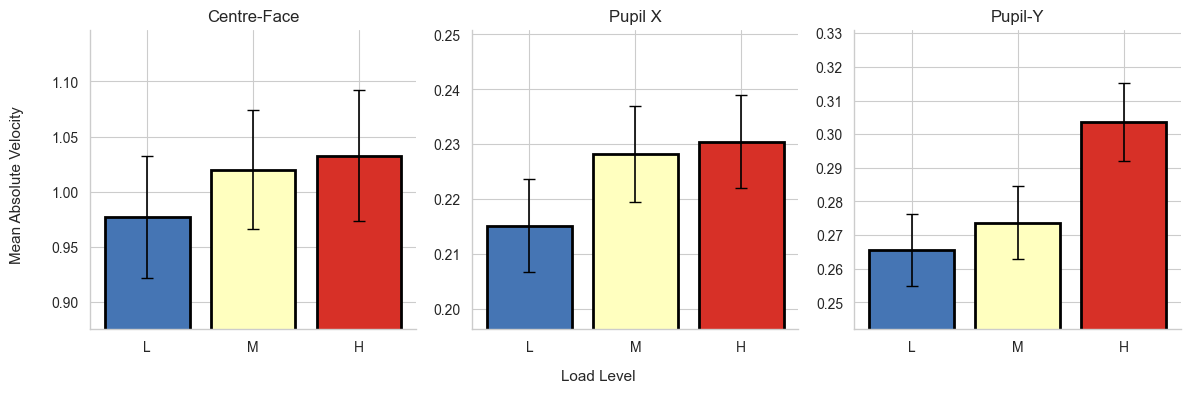

In [5]:
# === Style ===
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

title_fontsize = 12
axis_label_fontsize = 11
tick_fontsize = 10

# === Load and clean ===
df = pd.read_csv('data/linear_pose_metrics/experimental_pose_metrics.csv', sep=',')
df.columns = df.columns.str.strip()

# Map and order conditions
condition_map = {'L': 'Low', 'M': 'Moderate', 'H': 'High'}
df['condition_label'] = df['condition'].map(condition_map)
df['load_level'] = pd.Categorical(df['condition_label'], categories=['Low', 'Moderate', 'High'], ordered=True)

# === Target metrics for velocity ===
metrics = {
    'head_rotation_angle_mean_abs_vel': 'Centre-Face',
    'avg_pupil_x_mean_abs_vel': 'Pupil X',
    'avg_pupil_y_mean_abs_vel': 'Pupil-Y',
}

# Color palette
condition_palette = {'Low': '#4575b4', 'Moderate': '#ffffbf', 'High': '#d73027'}
tick_labels = {'Low': 'L', 'Moderate': 'M', 'High': 'H'}

# === Plotting ===
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

ylims = {
    'Centre-Face': (1.2, 1.55),
    'Pupil Y': (2.1, 2.55),
    'Mouth-Aperture': (15.5, 18),
}

for idx, (metric, region_label) in enumerate(metrics.items()):
    # Collapse per participant × condition
    collapsed = (
        df.groupby(['participant', 'load_level'])[metric]
        .mean()
        .reset_index()
    )

    # Summary stats
    summary = (
        collapsed.groupby('load_level')[metric]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    summary['sem'] = summary['std'] / np.sqrt(summary['count'])

    # Plot
    ax = axes[idx]
    ax.bar(
        summary['load_level'],
        summary['mean'],
        yerr=summary['sem'],
        capsize=4,
        color=[condition_palette[level] for level in summary['load_level']],
        edgecolor='black',
        linewidth=2
    )

    # Style
    ax.set_title(f'{region_label}', fontsize=title_fontsize)
    #ax.set_ylim(*ylims[region_label])
    ymin = (summary['mean'] - summary['sem']).min() * 0.95
    ymax = (summary['mean'] + summary['sem']).max() * 1.05
    ax.set_ylim(ymin, ymax) 
    ax.set_xticks(range(3))
    ax.set_xticklabels([tick_labels[level] for level in summary['load_level']])
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)

# Global labels
fig.text(0.5, 0.01, 'Load Level', ha='center', fontsize=axis_label_fontsize)
fig.text(0.01, 0.5, 'Mean Absolute Velocity', va='center', rotation='vertical', fontsize=axis_label_fontsize)

sns.despine()
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])

# Save
os.makedirs("figs", exist_ok=True)
plt.savefig("figs/velocity_1x3_panel.png", dpi=300)
plt.show()


# RQA 
using Recurrence-Quantificaton-Analysis package, script found under process_pose/rqa_pose.py

## stats

In [ ]:
df = pd.read_csv("data/rqa/experimental_pose_rqa.csv")

signal_column = "center_face_magnitude"  # Change this to the column you want to analyze
metrics = [
    "perc_recur", "perc_determ", "maxl_found", 
    "mean_line_length", "std_line_length", "entropy",
    "laminarity", "trapping_time", "vmax", 
    "divergence", "trend_lower_diag"
]

reference_conditions = ["L"]

for metric in metrics:
    print(f"\n=== LME for {metric} in {signal_column} ===")

    df_filtered = df[df["column"] == signal_column].copy()
    df_filtered["condition"] = df_filtered["condition"].astype(str)

    if df_filtered.empty:
        print(f"Skipping: no data for {signal_column}")
        continue

    for ref in reference_conditions:
        print(f"\n--- Reference: {ref} ---")
        try:
            model = smf.mixedlm(
                f"{metric} ~ C(condition, Treatment(reference='{ref}'))",
                df_filtered,
                groups=df_filtered["participant"]
            )
            result = model.fit()
            print(result.summary().tables[1])
        except Exception as e:
            print(f"Model failed: {e}")


## Figs

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load and prepare data
df = pd.read_csv("data/rqa/experimental_pose_rqa.csv")

# Normalize and order conditions
df["condition"] = df["condition"].str.strip().replace({
    "Low": "L", "Moderate": "M", "High": "H",
    "low": "L", "moderate": "M", "high": "H"
})
df["condition"] = pd.Categorical(df["condition"], categories=["L", "M", "H"], ordered=True)

# Region label mapping (custom names here)
region_names = {
    "blink_dist": "Blink",
    "mouth_dist": "Mouth",
    "head_rotation_angle": "Yaw",
    "avg_pupil_magnitude": "Pupil Magnitude",
    "center_face_magnitude": "Center Face",
}

df["region_label"] = df["column"].map(region_names).fillna(df["column"])

# ---- Filter to only the mapped regions ----
allowed_regions = list(region_names.values())
df = df[df["region_label"].isin(allowed_regions)]

# Style setup
sns.set(style="ticks")
condition_palette = {'L': '#4575b4', 'M': '#ffffbf', 'H': '#d73027'}
title_fontsize = 20
tick_fontsize = 14
axis_label_fontsize = 18
custom_palette = [
    "#4b0082",  # Indigo
    "#dc143c",  # Crimson
    "#008080",  # Teal
    "#ffb300",  # Amber
    "#36454f"   # Charcoal
]

# Metrics to plot
metrics = ["perc_recur", "maxl_found"]
titles = {"perc_recur": "%REC", "maxl_found": "Maxline"}

# Set up side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, metric in zip(axes, metrics):
    # Compute group means
    summary = (
        df.groupby(["region_label", "condition"])[metric]
          .mean()
          .reset_index()
    )
    # Z-score within each region
    summary[metric + "_z"] = (
        summary.groupby("region_label")[metric]
               .transform(lambda x: (x - x.mean()) / x.std())
    )

    # Plot, restricting hue to only our allowed regions
    sns.lineplot(
        data=summary,
        x="condition", y=metric + "_z",
        hue="region_label", hue_order=allowed_regions,
        palette=custom_palette,
        marker="o", linewidth=2, ax=ax
    )

    # Styling
    ax.set_title(titles[metric], fontsize=title_fontsize)
    ax.set_xlabel("Load Level", fontsize=axis_label_fontsize)
    if metric == "perc_recur":
        ax.set_ylabel("Z-scored Value", fontsize=axis_label_fontsize)
    else:
        ax.set_ylabel("", fontsize=axis_label_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.set_xlim(-0.1, 2.1)
    # Thicken spines
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

# Consolidate legend
axes[0].legend_.remove()
axes[1].legend_.remove()
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Region",
    bbox_to_anchor=(1.01, .70), loc='upper left', borderaxespad=0.
)

plt.tight_layout()

# Save figure
os.makedirs("figs", exist_ok=True)
plt.savefig(
    "figs/lineplots_zscore_rec_det.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
from rqa.utils.rqa_utils_cpp import rqa_dist
from rqa.utils.norm_utils import normalize_data

PARAMS = {
    "norm": 1,
    "eDim": 4,
    "tLag": 20,
    "rescaleNorm": 1,
    "radius": 0.15,
    "tw": 2,
    "minl": 4,
}

ROOT_DIR  = "data/experimental_pose"
PARTICIPANT = "454_01"  
SIGNAL = "avg_pupil_x"
WINDOW_LEN = 60 * 60  # 60 seconds at 60 Hz

def load_segment(pid, cond):
    fname = f"{pid}_{cond}.csv"
    df = pd.read_csv(os.path.join(ROOT_DIR, fname))
    if SIGNAL not in df.columns:
        raise ValueError(f"{SIGNAL} not found in {fname}")
    return df[SIGNAL].values[:WINDOW_LEN]

def compute_rp(series, p):
    series = normalize_data(series, p["norm"])
    ds = rqa_dist(series, series, dim=p["eDim"], lag=p["tLag"])
    return ds["d"] < p["radius"]

# Load signals
signals = {
    cond: load_segment(PARTICIPANT, cond)
    for cond in ["L", "M", "H"]
}

# Compute recurrence plots
rps = {
    cond: compute_rp(sig, PARAMS)
    for cond, sig in signals.items()
}

SAMPLE_RATE = 60  # Hz
DURATION = 60     # seconds
TICKS_SEC = [0, 15, 30, 45, 60]
TICKS_FRAMES = [t * SAMPLE_RATE for t in TICKS_SEC]

fig, axs = plt.subplots(1, 3, figsize=(10, 4), sharex=True)

for i, cond in enumerate(["L", "M", "H"]):
    ax = axs[i]
    rp = rps[cond].astype(float)
    im = ax.imshow(rp, cmap='Greys', origin='lower', vmin=0, vmax=1)
    ax.set_title(f"{cond}")
    ax.set_xticks(TICKS_FRAMES)
    ax.set_xticklabels(TICKS_SEC)
    ax.set_yticks(TICKS_FRAMES)
    ax.set_yticklabels(TICKS_SEC)
    ax.set_aspect('equal', adjustable='box')
    if i == 0:
        ax.set_ylabel("Time (s)")
    else:
        ax.set_yticks([])  
        ax.set_yticklabels([])
    ax.set_xlabel("Time (s)")

plt.subplots_adjust(wspace=0.1)
#fig.suptitle(f"Recurrence Plots – {SIGNAL.replace('_', ' ').title()}, Participant {PARTICIPANT}", y=1.08)
plt.show()

# CRQA
using Recurrence-Quantificaton-Analysis package, script found under process_pose/crqa_pose.py

## stats

In [ ]:
df = pd.read_csv("data/rqa/experimental_pose_rqa.csv")

signal_column = "crqa_eye_head"  # Change this to the column you want to analyze
metrics = [
    "perc_recur", "perc_determ", "maxl_found", 
    "mean_line_length", "std_line_length", "entropy",
    "laminarity", "trapping_time", "vmax", 
    "divergence", "trend_lower_diag"
]

reference_conditions = ["L"]

for metric in metrics:
    print(f"\n=== LME for {metric} in {signal_column} ===")

    df_filtered = df[df["column"] == signal_column].copy()
    df_filtered["condition"] = df_filtered["condition"].astype(str)

    if df_filtered.empty:
        print(f"Skipping: no data for {signal_column}")
        continue

    for ref in reference_conditions:
        print(f"\n--- Reference: {ref} ---")
        try:
            model = smf.mixedlm(
                f"{metric} ~ C(condition, Treatment(reference='{ref}'))",
                df_filtered,
                groups=df_filtered["participant"]
            )
            result = model.fit()
            print(result.summary().tables[1])
        except Exception as e:
            print(f"Model failed: {e}")


## figs

In [ ]:
from pathlib import Path

# ── STYLE ────────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

TITLE_FS   = 12
AXIS_FS    = 11
TICK_FS    = 10
SUPTITLE_FS = 14

condition_palette = {"L": "#4575b4", "M": "#ffffbf", "H": "#d73027"}

# ── LOAD & PREP ──────────────────────────────────────────────────────────
csv_path = Path("data/rqa/experimental_pose_rqa.csv")

df = pd.read_csv(csv_path)

df = df[df["column"] == "crqa_eye_head"].copy()

# Extract trailing load letter (L/M/H) from strings like '01_01_L'
df["condition"] = df["condition"].str.extract(r"([LMH])$")

# Map to descriptive & ordered category
cond_map = {"L": "Low", "M": "Moderate", "H": "High"}
df["load_level"] = pd.Categorical(df["condition"].map(cond_map),
                                  categories=["Low", "Moderate", "High"],
                                  ordered=True)

# ── RESHAPE ──────────────────────────────────────────────────────────────
metric_cols = {
    "perc_recur":        "% Recurrence",
    "mean_line_length":  "Mean Line Length",
    "trapping_time":     "Trapping Time",
}

long_df = (df
           .melt(id_vars=["participant", "load_level"],
                 value_vars=list(metric_cols.keys()),
                 var_name="metric", value_name="value")
           .assign(metric=lambda x: x["metric"].map(metric_cols)))

# ── SUMMARY STATS ────────────────────────────────────────────────────────
summary = (long_df
           .groupby(["metric", "load_level"], as_index=False)
           .agg(mean=("value", "mean"),
                std=("value", "std"),
                n=("value", "count")))
summary["sem"] = summary["std"] / np.sqrt(summary["n"])
summary["sem"] = summary["sem"].fillna(0)          # guard against NaNs

# Re-shorten load labels (Low→L etc.)
lvl_map = {"Low": "L", "Moderate": "M", "High": "H"}
summary["load_level"] = pd.Categorical(summary["load_level"].map(lvl_map),
                                       categories=["L", "M", "H"], ordered=True)

# ── PLOT ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=False)

for ax, metric_label in zip(axes, metric_cols.values()):
    sub = summary[summary["metric"] == metric_label]

    # Draw bars
    bars = ax.bar(
        sub["load_level"],
        sub["mean"],
        yerr=sub["sem"],
        capsize=4,
        color=[condition_palette[lvl] for lvl in sub["load_level"]],
        edgecolor="black",
        linewidth=2
    )

    # Adaptive y-axis
    low  = (sub["mean"] - sub["sem"]).min()
    high = (sub["mean"] + sub["sem"]).max()
    span = high - low
    pad  = max(span * 0.03, 0.05)          # 3 % pad, ≥0.05
    ax.set_ylim(low - pad, high + pad)

    ax.set_title(metric_label, fontsize=TITLE_FS)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=TICK_FS)

    if ax is axes[0]:
        ax.set_ylabel("Value", fontsize=AXIS_FS)

# ── GLOBAL LAYOUT ────────────────────────────────────────────────────────
fig.suptitle("Gaze–Head Cross-Recurrence",
             fontsize=SUPTITLE_FS, y=.95)
fig.text(0.5, 0.01, "Load Condition", ha="center", fontsize=AXIS_FS)

# Box every axis
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

fig.tight_layout()
# os.makedirs("figures", exist_ok=True)
#fig.savefig("/Users/cartersale/Library/CloudStorage/OneDrive-MacquarieUniversity/Research/Projects/2025_MATBExp4/03_Analysis/figures/cross_recurrence_metrics.png", dpi=300, bbox_inches="tight")
#print("✓ Saved: figures/cross_recurrence_metrics.png")
